Classification Notebook

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [53]:
# --- Paths ---
FEATURES_PATH = "../data/features/leaf_features_professional.csv"
MODEL_PATH = "../models/leaf_classifier_svm_rbf.pkl"

In [54]:
# --- Load features ---
df = pd.read_csv(FEATURES_PATH)
X = df.drop('label', axis=1).values
y = df['label'].values

In [55]:
# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
# --- PCA ---
pca = PCA(n_components=80)
X_pca = pca.fit_transform(X_scaled)
print("PCA applied. Reduced features to 80 dimensions.")

PCA applied. Reduced features to 80 dimensions.


In [57]:
# --- SVM-RBF + Stratified 5-Fold CV ---
clf = SVC(kernel='rbf', C=10, gamma='scale')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(clf, X_pca, y, cv=skf)

In [58]:
# --- Accuracy & Macro F1 ---
accuracy = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred, average='macro')
print(f"Accuracy (CV): {accuracy:.4f}")
print(f"Macro F1-Score (CV): {f1:.4f}")

Accuracy (CV): 0.7343
Macro F1-Score (CV): 0.7378


In [59]:
# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y, y_pred))


Classification Report:
                              precision    recall  f1-score   support

             Acer_Capillipes       0.75      0.60      0.67        10
             Acer_Circinatum       1.00      1.00      1.00        10
                   Acer_Mono       1.00      0.80      0.89        10
                 Acer_Opalus       1.00      1.00      1.00        10
               Acer_Palmatum       1.00      0.90      0.95        10
                 Acer_Pictum       0.82      0.90      0.86        10
             Acer_Platanoids       1.00      0.80      0.89        10
                 Acer_Rubrum       1.00      1.00      1.00        10
              Acer_Rufinerve       1.00      1.00      1.00        10
            Acer_Saccharinum       0.90      0.90      0.90        10
               Alnus_Cordata       1.00      0.90      0.95        10
          Alnus_Maximowiczii       1.00      0.70      0.82        10
                 Alnus_Rubra       0.82      0.90      0.86      

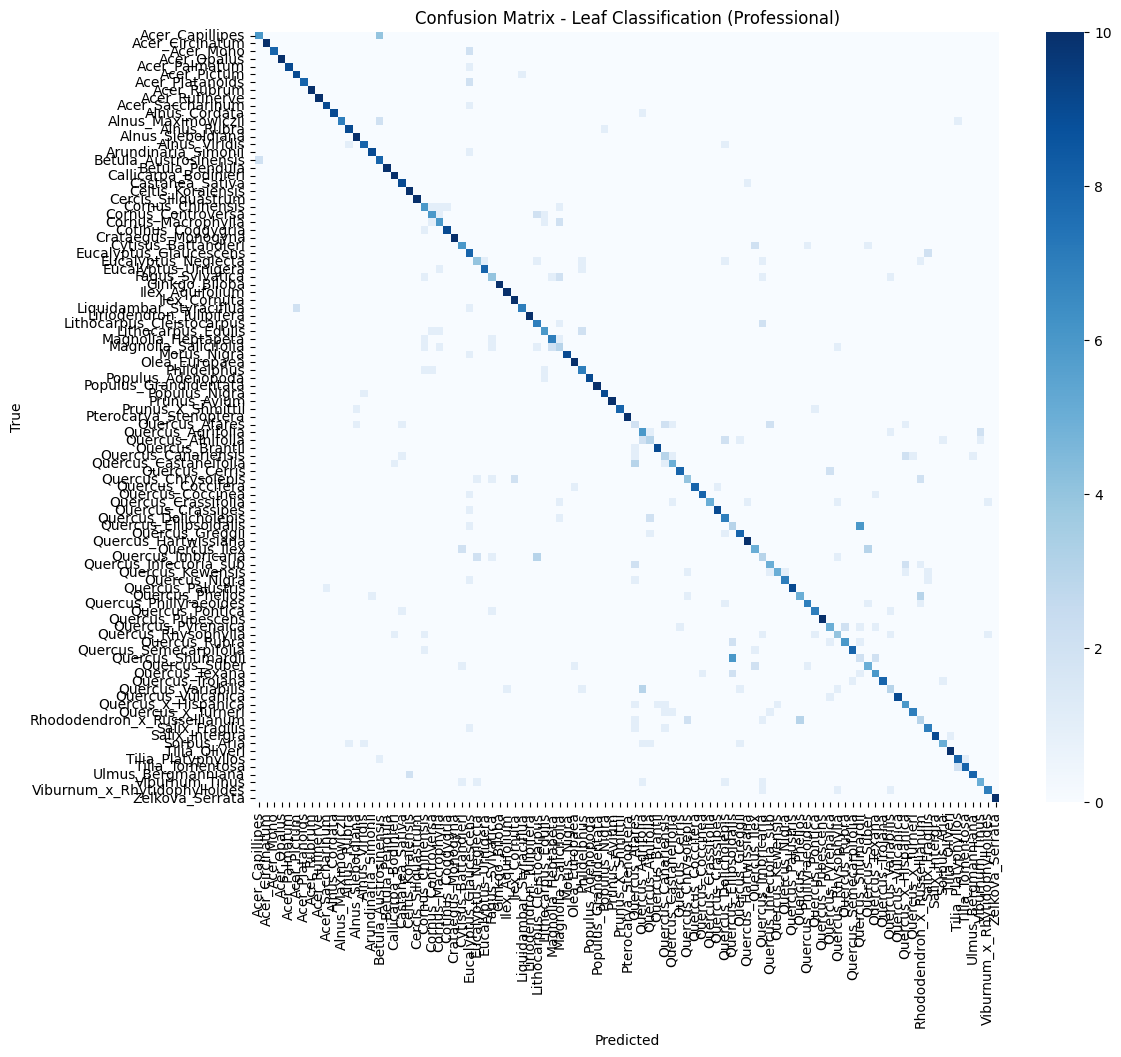

In [60]:
# --- Confusion Matrix ---
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, xticklabels=sorted(set(y)), yticklabels=sorted(set(y)), cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Leaf Classification (Professional)")
plt.show()

In [61]:
# --- Train final model on full dataset ---
clf.fit(X_pca, y)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [62]:
# --- Save model and scaler ---
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(clf, MODEL_PATH)
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(pca, "../models/pca.pkl")
print(f"Model, scaler, and PCA saved in ../models/")

Model, scaler, and PCA saved in ../models/
